## Comparison Figures

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
real_res = pd.read_csv('C:\\Users\\exmar\\Documents\\BU_Docs\\Classes\\Fall_25\\challenge project\\sgRNAtor\\Elm\\LeTRS_Analysis\\sgrna_count_matrix_real.csv')
sim_res = pd.read_csv('C:\\Users\\exmar\\Documents\\BU_Docs\\Classes\\Fall_25\\challenge project\\sgRNAtor\\Elm\\LeTRS_Analysis\\sgrna_count_matrix.csv')
sim_conf = pd.read_csv('C:\\Users\\exmar\\Documents\\BU_Docs\\Classes\\Fall_25\\challenge project\\sgRNAtor\\Elm\\LeTRS_Analysis\\simdata_per_sample_confusion.csv')
new_real = pd.read_csv('C:\\Users\\exmar\\Documents\\BU_Docs\\Classes\\Fall_25\\challenge project\\voc_summary.csv')

In [128]:
print(new_real.head())
real_res = new_real.merge(real_res[['sample', 'sgRNA', 'LeTRS_peak']], on=['sample', 'sgRNA'], how='left').reset_index(drop=True)
plot_data = real_res.copy()
plot_data = plot_data.melt(id_vars = ["sample", "sgRNA"], value_vars=["LeTRS_peak", "ditector_count", "sgrnator_count"], var_name = "tool", value_name = "count")
plot_data["sample"] = plot_data["sample"].str.split('-').str[0]

mapping_dict = {"alpha": "Alpha", "beta": "Beta", "delta": "Delta", "omicron": "Omicron", "b.1": "Wuhan", "ba.2": "Omicron", "gamma":"Gamma"}

plot_data["sample"] = plot_data["sample"].map(mapping_dict)


        sample  sgRNA  ditector_count  letrs_cluster_count  sgrnator_count
0  alpha-00148      S           622.0                566.0           474.0
1  alpha-00148  ORF3a             6.0                  6.0             3.0
2  alpha-00148      E             4.0                  2.0             1.0
3  alpha-00148      M           370.0                275.0           296.0
4  alpha-00148   ORF6           186.0                193.0           148.0


c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be remov

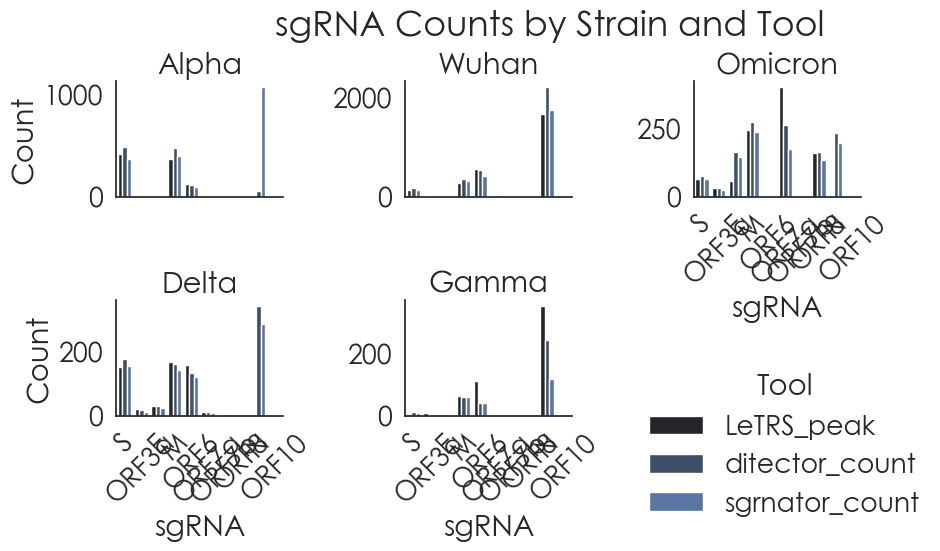

In [123]:
grid = sns.FacetGrid(plot_data, col="sample", col_wrap=3, sharey=False, legend_out=True, height = 2.5, aspect = 1.25)
grid.map(sns.barplot, "sgRNA", "count", data = plot_data, hue = "tool", order = plot_data["sgRNA"].unique(), errorbar = None)
grid.set_titles("{col_name}")
grid.set_axis_labels("sgRNA", "Count")
grid.set_xticklabels(labels=plot_data["sgRNA"].unique(), rotation=45)
grid.add_legend(title = "Tool", bbox_to_anchor=(0.82, 0.15))
plt.suptitle("sgRNA Counts by Strain and Tool", y=1.02)
plt.show()

['S', 'M', 'E', 'ORF3a', 'ORF6', 'ORF7a', 'ORF7b', 'ORF8', 'N', 'ORF10', 'Alpha', 'Wuhan', 'Omicron', 'Delta', 'Gamma']


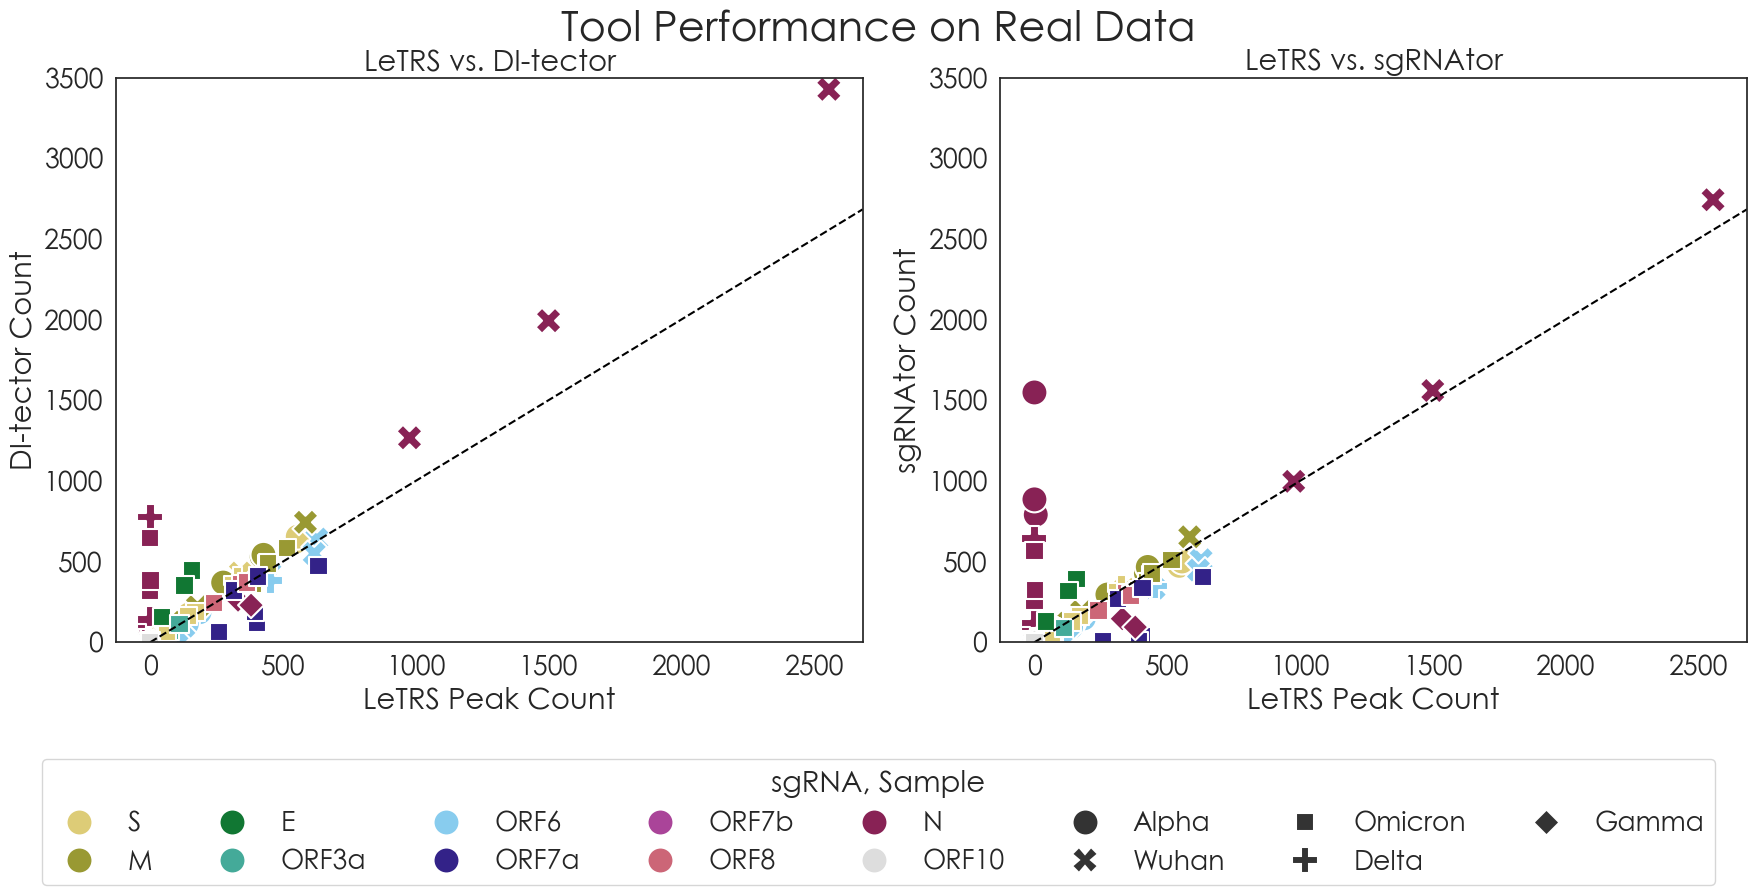

In [234]:
new_plt_data = real_res.copy()
new_plt_data["sample"] = new_plt_data["sample"].str.split('-').str[0]
mapping_dict = {"alpha": "Alpha", "beta": "Beta", "delta": "Delta", "omicron": "Omicron", "b.1": "Wuhan", "ba.2": "Omicron", "gamma":"Gamma"}
new_plt_data["sample"] = new_plt_data["sample"].map(mapping_dict)
real_palette = ["#DDCC77", "#999933", "#117733", "#44AA99", "#88CCEE", "#332288", "#AA4499", "#CC6677", "#882255", "#DDDDDD"]
hue_ord = ["S", "M", "E", "ORF3a", "ORF6", "ORF7a", "ORF7b", "ORF8", "N", "ORF10"]
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

ax1.axline((0, 0), slope=1, color='black', linestyle='--')
ax2.axline((0, 0), slope=1, color='black', linestyle='--')

sns.scatterplot(data=new_plt_data, x="LeTRS_peak", y="sgrnator_count", hue="sgRNA", hue_order = hue_ord, palette = real_palette, style="sample", ax = ax1, s=350)

sns.scatterplot(data=new_plt_data, x="LeTRS_peak", y="ditector_count", hue="sgRNA", hue_order = hue_ord, palette = real_palette, style="sample", ax = ax2, s = 350, legend = False)
handles, labels = ax1.get_legend_handles_labels()
del handles[11]
del labels[11]
del handles[0]
del labels[0]
print(labels)
ax1.get_legend().remove()
fig.legend(
    handles, labels, 
    bbox_to_anchor=(0.5, 0), ncol=8,
    title = "sgRNA, Sample",
    loc = "upper center"
)

ax1.set_xlabel("LeTRS Peak Count")
ax1.set_ylabel("sgRNAtor Count")
ax1.set_title("LeTRS vs. sgRNAtor")
ax2.set_xlabel("LeTRS Peak Count")
ax2.set_ylabel("DI-tector Count")
ax2.set_title("LeTRS vs. DI-tector")
ax1.set_ylim(0, 3500)
ax2.set_ylim(0, 3500)
plt.suptitle("Tool Performance on Real Data", fontsize = 30, y = 0.92)
plt.tight_layout()
plt.show()

In [19]:
sim_plot_data = sim_res.copy()
sim_plot_data["og_sample"] = sim_plot_data["sample"]
sim_plot_data["sample"] = sim_plot_data["sample"].str[:-5]
sim_plot_data = sim_plot_data.melt(id_vars = ["og_sample","sample", "sgRNA"], value_vars=["LeTRS_cluster", "DI-tector", "sgRNAtor", "ground_truth"], var_name = "tool", value_name = "count")

sim_plot_data = sim_plot_data[sim_plot_data["sample"].isin(["Exponential_Decay", "N_Dominant", "Sparse_1", "Ultra-Sparse_1", "Uniform"])]

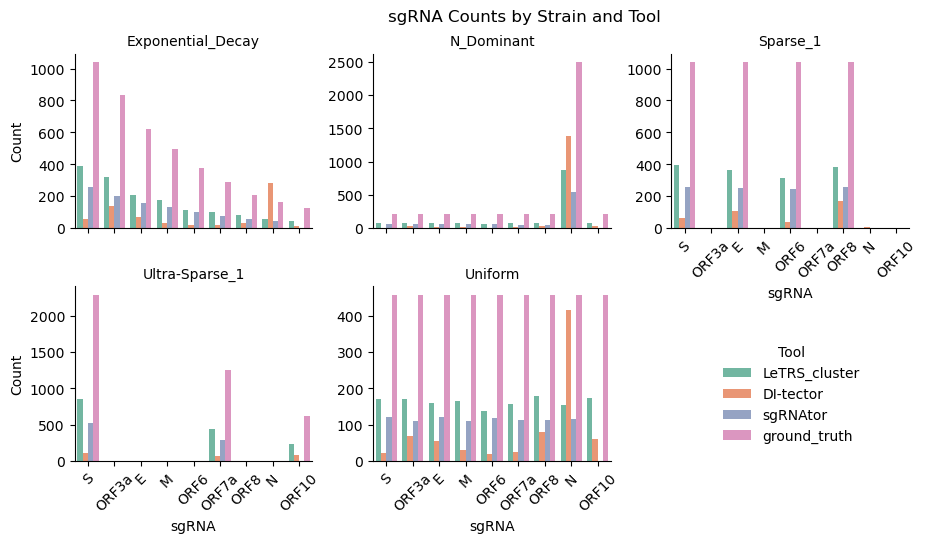

In [8]:
grid = sns.FacetGrid(sim_plot_data, col="sample", col_wrap=3, sharey=False, legend_out=True, height = 2.5, aspect = 1.25)
grid.map(sns.barplot, "sgRNA", "count", data = sim_plot_data, hue = "tool", palette = "Set2", order = sim_plot_data["sgRNA"].unique(), errorbar = None)
grid.set_titles("{col_name}")
grid.set_axis_labels("sgRNA", "Count")
grid.set_xticklabels(labels=sim_plot_data["sgRNA"].unique(), rotation=45)
grid.add_legend(title = "Tool", bbox_to_anchor=(0.82, 0.25))
plt.suptitle("sgRNA Counts by Strain and Tool", y=1.02)
plt.show()

In [20]:
prop_sim_plot = sim_plot_data.copy()
prop_sim_plot["proportion"] = prop_sim_plot.groupby(["og_sample", "tool", "sgRNA"])["count"].transform("sum") / prop_sim_plot.groupby(["og_sample", "tool"])["count"].transform("sum")
#prop_sim_plot["sample"] = prop_sim_plot["sample"].str[:-5]
prop_sim_plot

,og_sample,sample,sgRNA,tool,count,proportion
27,Exponential_Decay_rep1,Exponential_Decay,S,LeTRS_cluster,402.0,0.265522
28,Exponential_Decay_rep1,Exponential_Decay,ORF3a,LeTRS_cluster,319.0,0.210700
29,Exponential_Decay_rep1,Exponential_Decay,E,LeTRS_cluster,189.0,0.124835
30,Exponential_Decay_rep1,Exponential_Decay,M,LeTRS_cluster,182.0,0.120211
31,Exponential_Decay_rep1,Exponential_Decay,ORF6,LeTRS_cluster,109.0,0.071995
...,...,...,...,...,...,...
1291,Uniform_rep3,Uniform,ORF6,ground_truth,458.0,0.111111
1292,Uniform_rep3,Uniform,ORF7a,ground_truth,458.0,0.111111
1293,Uniform_rep3,Uniform,ORF8,ground_truth,458.0,0.111111
1294,Uniform_rep3,Uniform,N,ground_truth,458.0,0.111111


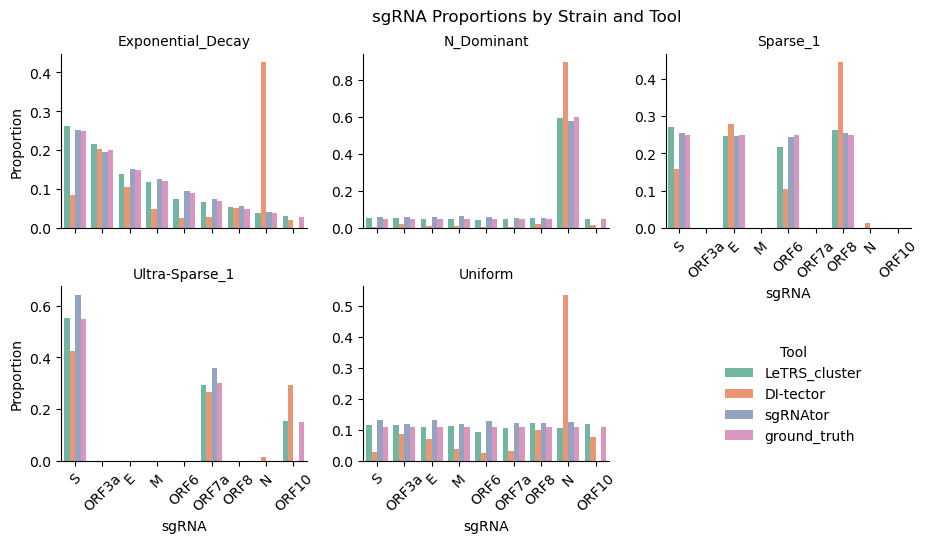

In [21]:
grid = sns.FacetGrid(prop_sim_plot, col="sample", col_wrap=3, sharey=False, legend_out=True, height = 2.5, aspect = 1.25)
grid.map(sns.barplot, "sgRNA", "proportion", data = prop_sim_plot, hue = "tool", palette = "Set2", order = prop_sim_plot["sgRNA"].unique(), errorbar = None)
grid.set_titles("{col_name}")
grid.set_axis_labels("sgRNA", "Proportion")
grid.set_xticklabels(labels=prop_sim_plot["sgRNA"].unique(), rotation=45)
grid.add_legend(title = "Tool", bbox_to_anchor=(0.82, 0.25))
plt.suptitle("sgRNA Proportions by Strain and Tool", y=1.02)
plt.show()

In [24]:
prop_gt_plot = sim_res.copy()
prop_gt_plot["og_sample"] = prop_gt_plot["sample"]
prop_gt_plot["sample"] = prop_gt_plot["sample"].str[:-5]
prop_gt_plot = prop_gt_plot.melt(id_vars = ["og_sample","sample", "sgRNA", "ground_truth"], value_vars=["LeTRS_cluster", "DI-tector", "sgRNAtor"], var_name = "tool", value_name = "count")
prop_gt_plot["proportion"] = prop_gt_plot["count"]/prop_gt_plot["ground_truth"]
#prop_sim_plot["sample"] = prop_sim_plot["sample"].str[:-5]
prop_gt_plot

,og_sample,sample,sgRNA,ground_truth,tool,count,proportion
0,E_Dominant_rep1,E_Dominant,S,208,LeTRS_cluster,66.0,0.317308
1,E_Dominant_rep1,E_Dominant,ORF3a,208,LeTRS_cluster,78.0,0.375000
2,E_Dominant_rep1,E_Dominant,E,2499,LeTRS_cluster,849.0,0.339736
3,E_Dominant_rep1,E_Dominant,M,208,LeTRS_cluster,68.0,0.326923
4,E_Dominant_rep1,E_Dominant,ORF6,208,LeTRS_cluster,69.0,0.331731
...,...,...,...,...,...,...,...
967,Uniform_rep3,Uniform,ORF6,458,sgRNAtor,107.0,0.233624
968,Uniform_rep3,Uniform,ORF7a,458,sgRNAtor,116.0,0.253275
969,Uniform_rep3,Uniform,ORF8,458,sgRNAtor,115.0,0.251092
970,Uniform_rep3,Uniform,N,458,sgRNAtor,107.0,0.233624


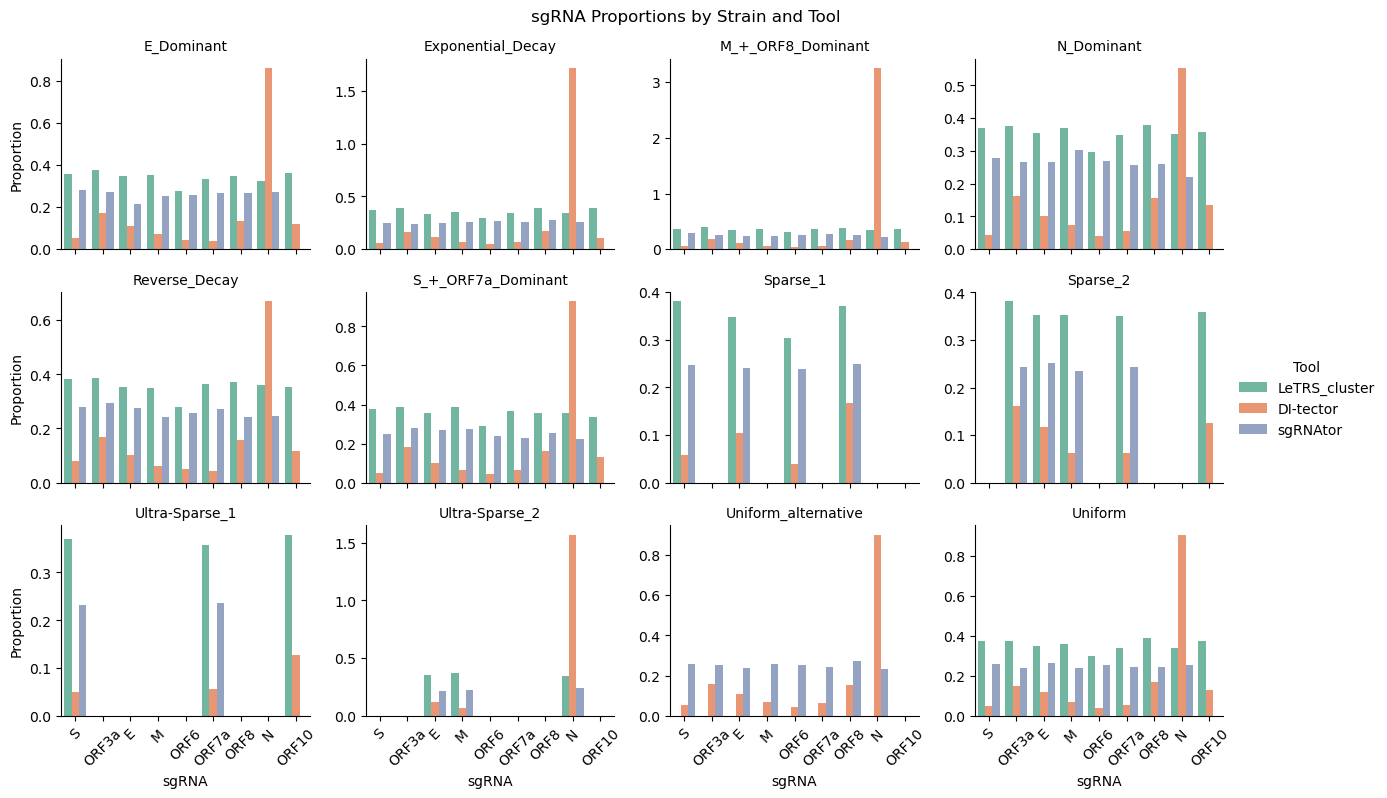

In [27]:
grid = sns.FacetGrid(prop_gt_plot, col="sample", col_wrap=4, sharey=False, legend_out=True, height = 2.5, aspect = 1.25)
grid.map(sns.barplot, "sgRNA", "proportion", data = prop_gt_plot, hue = "tool", palette = "Set2", order = prop_gt_plot["sgRNA"].unique(), errorbar = None)
grid.set_titles("{col_name}")
grid.set_axis_labels("sgRNA", "Proportion")
grid.set_xticklabels(labels=prop_gt_plot["sgRNA"].unique(), rotation=45)
grid.add_legend(title = "Tool")
plt.suptitle("sgRNA Proportions by Strain and Tool", y=1.02)
plt.show()

In [43]:
sim_conf = pd.read_csv('C:\\Users\\exmar\\Documents\\BU_Docs\\Classes\\Fall_25\\challenge project\\sgRNAtor\\Elm\\LeTRS_Analysis\\simdata_per_sample_confusion.csv')
sim_conf["sample_cat"] = sim_conf["sample"].str[:-5]
sim_conf = sim_conf[sim_conf["sample_cat"] != "Uniform_(alternative)"]

sim_conf["DI-tector_precision"] = sim_conf["DI-tector_TP"] / (sim_conf["DI-tector_TP"] + sim_conf["DI-tector_FP"])
sim_conf["DI-tector_recall"] = sim_conf["DI-tector_TP"]/ (sim_conf["DI-tector_TP"] + sim_conf["DI-tector_FN"])
sim_conf["LeTRS_precision"] = sim_conf["LeTRS_TP"] / (sim_conf["LeTRS_TP"] + sim_conf["LeTRS_FP"])
sim_conf["LeTRS_recall"] = sim_conf["LeTRS_TP"]/ (sim_conf["LeTRS_TP"] + sim_conf["LeTRS_FN"])
sim_conf["sgRNAtor_precision"] = sim_conf["sgRNAtor_TP"] / (sim_conf["sgRNAtor_TP"] + sim_conf["sgRNAtor_FP"])
sim_conf["sgRNAtor_recall"] = sim_conf["sgRNAtor_TP"]/ (sim_conf["sgRNAtor_TP"] + sim_conf["sgRNAtor_FN"])


sim_conf_piv = sim_conf.melt(id_vars = ["sample", "sample_cat"], value_vars=["DI-tector_TP", "DI-tector_FP", "DI-tector_FN", "DI-tector_total_called",\
                                                                        "LeTRS_TP", "LeTRS_FP", "LeTRS_FN", "LeTRS_total_called", \
                                                                        "sgRNAtor_TP", "sgRNAtor_FP", "sgRNAtor_FN", "sgRNAtor_total_called",\
                                                                        "DI-tector_precision", "DI-tector_recall", "LeTRS_precision", "LeTRS_recall", \
                                                                        "sgRNAtor_precision", "sgRNAtor_recall"], var_name = "tool", value_name = "value")
sim_conf_piv["metric"] = sim_conf_piv["tool"].str.split("_").str[1]
sim_conf_piv["tool"] = sim_conf_piv["tool"].str.split("_").str[0]
sim_conf_piv["sample_cat_2"] = sim_conf_piv["sample_cat"].map({"Exponential_Decay": "Decay", "N_Dominant": "N Dominant", "Sparse_1": "Sparse", "Ultra-Sparse_1": "Ultra-Sparse", "Uniform": "Uniform",\
                                                             "Reverse_Decay": "Decay", "E_Dominant": "Dominant", "M_+_ORF8_Dominant": "Dominant", "S_+_ORF7a_Dominant": "Dominant",\
                                                                "Sparse_2": "Sparse", "Ultra-Sparse_2": "Ultra-Sparse"})


sim_conf_piv = sim_conf_piv.pivot(index = ["sample", "sample_cat", "sample_cat_2", "tool"], columns="metric", values = "value").reset_index()
sim_conf_piv = sim_conf_piv.groupby(["sample_cat_2", "tool"]).sum().reset_index()
sim_conf_piv["Precision"] = sim_conf_piv["TP"] / (sim_conf_piv["TP"] + sim_conf_piv["FP"])
sim_conf_piv["Recall"] = sim_conf_piv["TP"] / (sim_conf_piv["TP"] + sim_conf_piv["FN"])
sim_conf_piv = sim_conf_piv.melt(id_vars = ["sample_cat_2", "tool"], value_vars=["Precision", "Recall"], var_name = "metric", value_name = "value")

plot_conf = sim_conf_piv[sim_conf_piv["tool"].isin(["LeTRS", "DI-tector"])]

# Want to add a ground truth column to this graph

c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


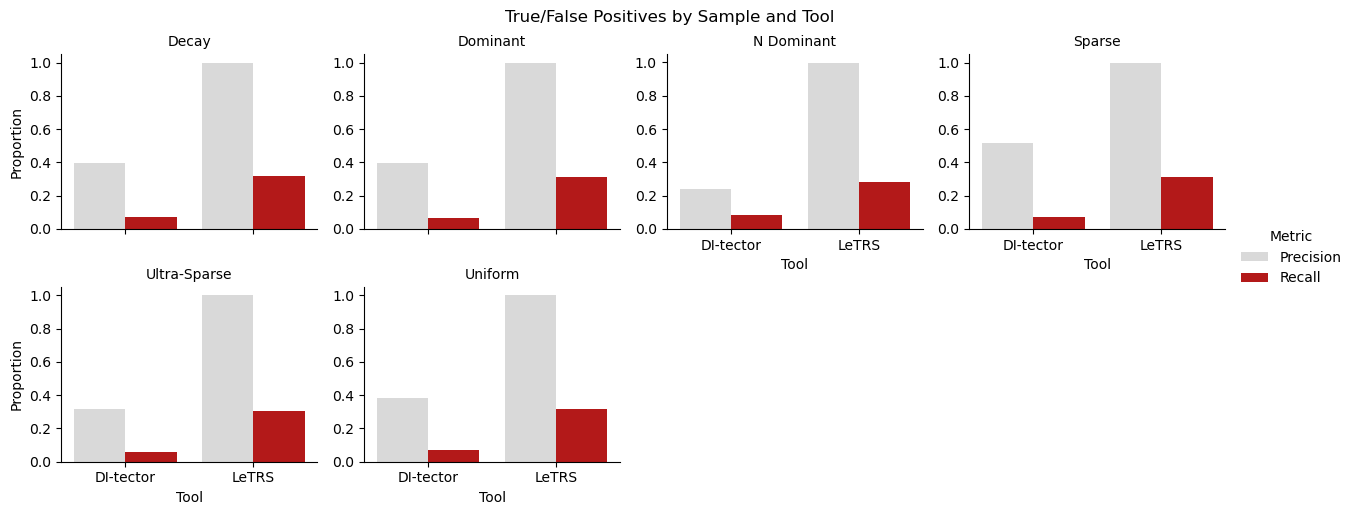

In [44]:
my_palette = ["#d9d9d9", "#CC0000"]
grid = sns.FacetGrid(plot_conf, col="sample_cat_2", col_wrap=4, sharey=False, legend_out=True, height = 2.5, aspect = 1.25)
grid.map(sns.barplot, "tool", "value", data = plot_conf, hue = "metric", palette = my_palette, errorbar = None)
grid.set_titles("{col_name}")
grid.set_axis_labels("Tool", "Proportion")
grid.add_legend(title = "Metric")
plt.suptitle("True/False Positives by Sample and Tool", y=1.02)
plt.show()

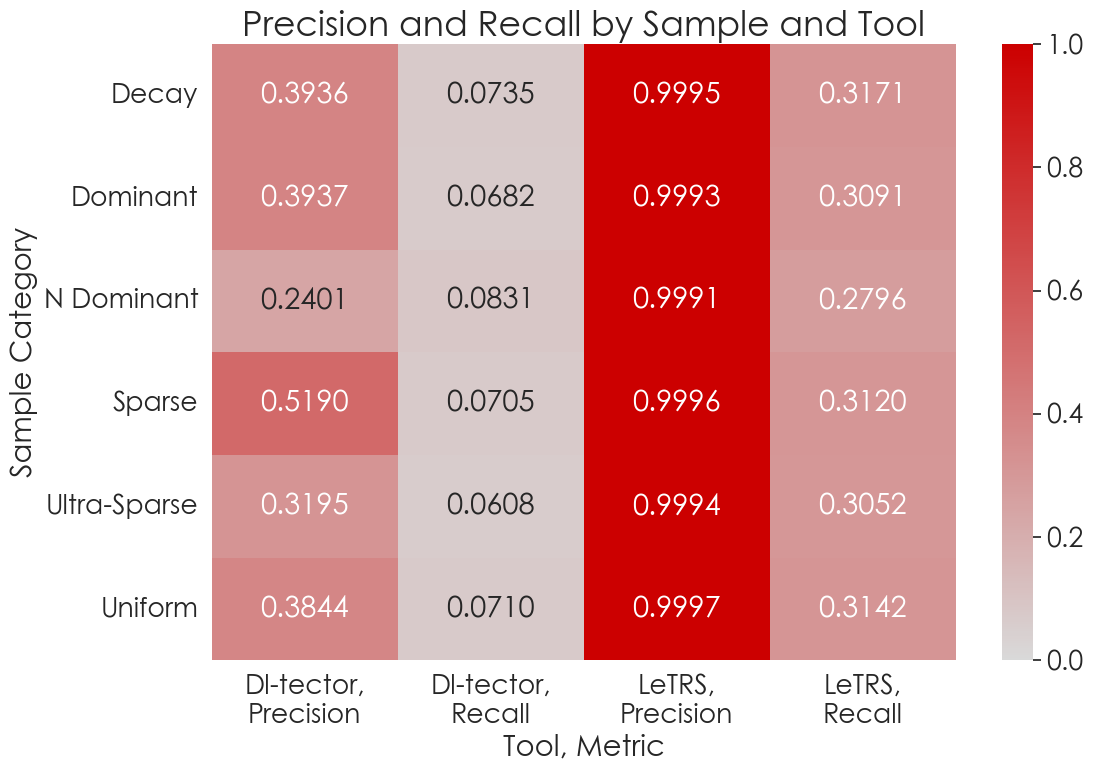

In [104]:
import matplotlib
matplotlib.font_manager.fontManager.addfont('C:\\Windows\\Fonts\\GOTHIC.ttf')
sns.set_theme(style="white", font='Century Gothic',font_scale=1.75)
plot_conf["tm"] = plot_conf["tool"] + ",\n" + plot_conf["metric"]
plot_conf_piv = plot_conf.pivot(index = "sample_cat_2", columns = "tm", values = "value")
my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom_name", my_palette)
plt.figure(figsize = (12, 8))
sns.heatmap(plot_conf_piv, annot = True, cmap = my_cmap, vmin = 0, vmax = 1, fmt='.4f')
plt.title("Precision and Recall by Sample and Tool", fontsize = 25)
plt.xlabel("Tool, Metric")
plt.ylabel("Sample Category")
plt.show()

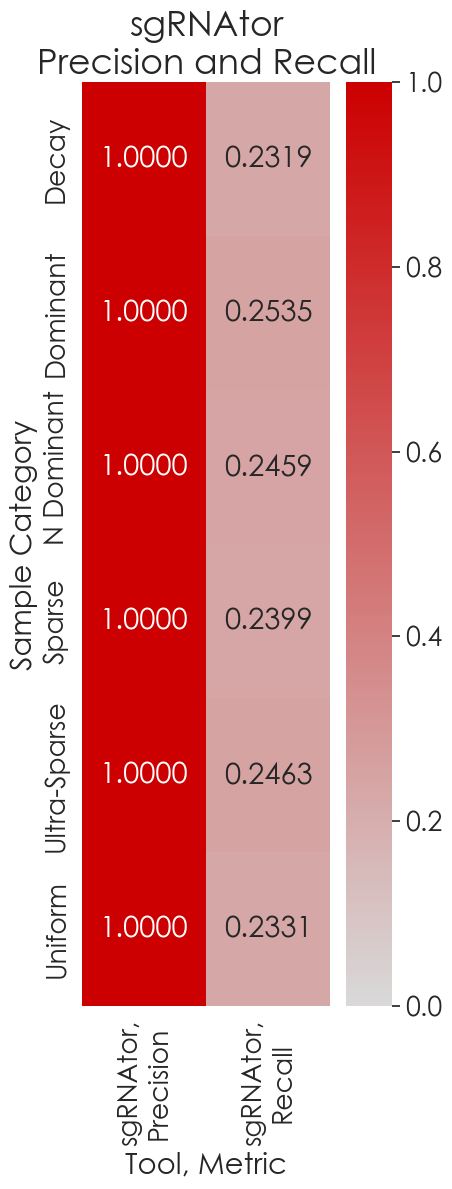

In [226]:
sg_plot = sim_conf_piv[sim_conf_piv["tool"]== "sgRNAtor"]
sg_plot["tm"] = sg_plot["tool"] + ",\n" + sg_plot["metric"]
sg_plot = sg_plot.pivot(index = "sample_cat_2", columns = "tm", values = "value")
plt.figure(figsize=(4,12))
sns.heatmap(sg_plot, annot = True, cmap = my_cmap, vmin = 0, vmax = 1, fmt='.4f')
plt.title("sgRNAtor\nPrecision and Recall", fontsize = 25)
plt.xlabel("Tool, Metric")
plt.ylabel("Sample Category")
#plt.xticks(rotation=25)
plt.show()